In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/sdd_preprocessed.csv")

In [3]:
df.isnull().sum()

Gender                0
Age                   0
City                  0
Profession            0
Academic Pressure     0
Work Pressure         0
CGPA                  0
Study Satisfaction    0
Job Satisfaction      0
Sleep Duration        0
Dietary Habits        0
Degree_Field          0
Suicidal Thoughts     0
Work/Study Hours      0
Financial Stress      0
FM Mental Illness     0
Depression            0
dtype: int64

In [4]:
df.columns

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree_Field', 'Suicidal Thoughts',
       'Work/Study Hours', 'Financial Stress', 'FM Mental Illness',
       'Depression'],
      dtype='str')

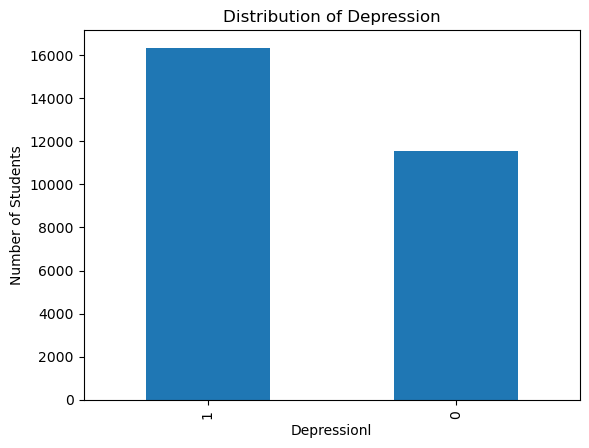

In [5]:
import matplotlib.pyplot as plt

df["Depression"].value_counts().plot(kind="bar")
plt.title("Distribution of Depression")
plt.xlabel("Depressionl")
plt.ylabel("Number of Students")
plt.show()

In [6]:
df.shape

(27901, 17)

In [7]:
df["Work Pressure"].value_counts()

Work Pressure
0    27898
5        2
2        1
Name: count, dtype: int64

<Axes: xlabel='Work Pressure', ylabel='Depression'>

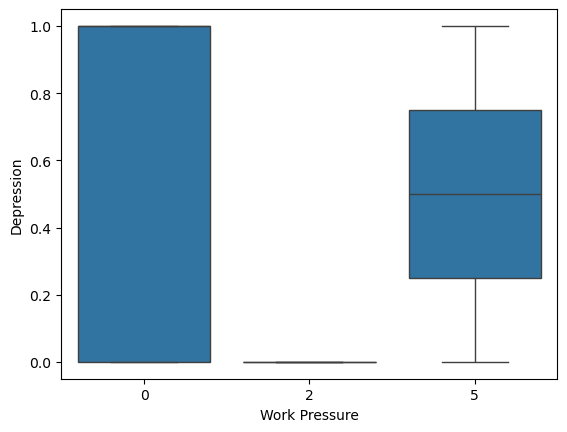

In [8]:
import seaborn as sns
sns.boxplot(x="Work Pressure", y="Depression", data=df)

<Axes: xlabel='Job Satisfaction', ylabel='Depression'>

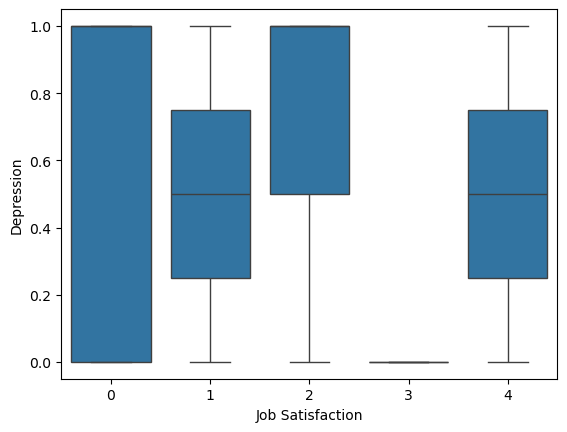

In [9]:
import seaborn as sns
sns.boxplot(x="Job Satisfaction", y="Depression", data=df)

In [10]:
df["Dietary Habits"].value_counts(dropna=False)

Dietary Habits
3    10329
2     9921
1     7651
Name: count, dtype: int64

In [11]:
df["Financial Stress"].value_counts(dropna=False)

Financial Stress
5    6718
4    5775
3    5226
1    5121
2    5061
Name: count, dtype: int64

In [12]:
df["Dietary Habits"].value_counts(dropna=False)

Dietary Habits
3    10329
2     9921
1     7651
Name: count, dtype: int64

In [13]:
df["Financial Stress"].value_counts(dropna=False)

Financial Stress
5    6718
4    5775
3    5226
1    5121
2    5061
Name: count, dtype: int64

In [14]:
corr_with_depression = df.corr()["Depression"].sort_values(ascending=False)

print(corr_with_depression)

Depression            1.000000
Suicidal Thoughts     0.546277
Academic Pressure     0.474835
Financial Stress      0.363464
Dietary Habits        0.206671
Work/Study Hours      0.196983
Degree_Field          0.068172
FM Mental Illness     0.053430
CGPA                  0.040106
Profession            0.018472
City                  0.004761
Gender               -0.001794
Work Pressure        -0.003351
Job Satisfaction     -0.003482
Sleep Duration       -0.086690
Study Satisfaction   -0.167971
Age                  -0.189802
Name: Depression, dtype: float64


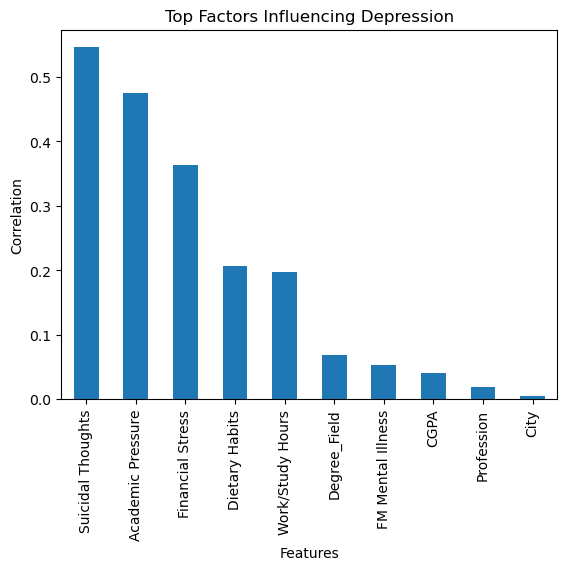

In [15]:
import matplotlib.pyplot as plt

corr_with_depression.drop("Depression").head(10).plot(kind="bar")

plt.title("Top Factors Influencing Depression")
plt.ylabel("Correlation")
plt.xlabel("Features")
plt.show()

In [16]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    }

lr_results = evaluate_model(y_test, y_pred_lr)
dt_results = evaluate_model(y_test, y_pred_dt)
rf_results = evaluate_model(y_test, y_pred_rf)

print("Logistic Regression:", lr_results)
print("Decision Tree:", dt_results)
print("Random Forest:", rf_results)

Logistic Regression: {'Accuracy': 0.8330048378426805, 'Precision': 0.8324514905768091, 'Recall': 0.8330048378426805, 'F1 Score': 0.8324538638295963}
Decision Tree: {'Accuracy': 0.7572119691811503, 'Precision': 0.7574035813199852, 'Recall': 0.7572119691811503, 'F1 Score': 0.7573036333509054}
Random Forest: {'Accuracy': 0.8260168428597026, 'Precision': 0.8255179236100487, 'Recall': 0.8260168428597026, 'F1 Score': 0.8256457930616252}


In [23]:
import pandas as pd

results_df = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results
}).T

print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.833005   0.832451  0.833005  0.832454
Decision Tree        0.757212   0.757404  0.757212  0.757304
Random Forest        0.826017   0.825518  0.826017  0.825646


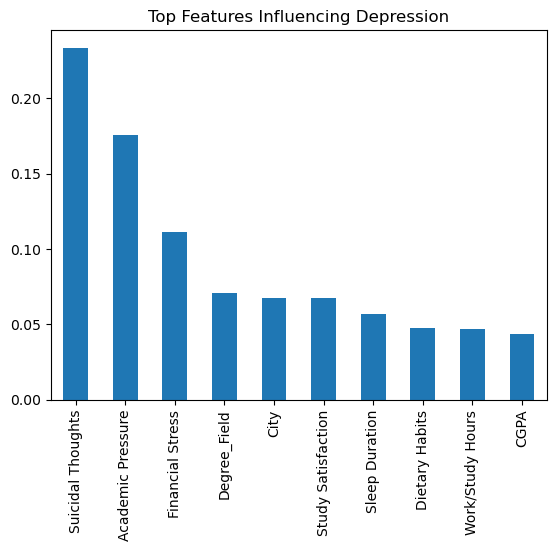

In [24]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Features Influencing Depression")
plt.show()

In [25]:
# Testing Edge Cases: Missing Values, Outliers, Multicollinearity

# Missing Values
# Create missing values
import numpy as np

df_missing = df.copy()

for col in df_missing.columns:
    df_missing.loc[df_missing.sample(frac=0.05).index, col] = np.nan

In [26]:
df_missing = df_missing.fillna(df_missing.mode().iloc[0])

In [27]:
#train model
X_m = df_missing.drop("Depression", axis=1)
y_m = df_missing["Depression"]

from sklearn.model_selection import train_test_split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

lr_m = LogisticRegression(max_iter=1000)
lr_m.fit(X_train_m, y_train_m)

y_pred_m = lr_m.predict(X_test_m)

from sklearn.metrics import accuracy_score
print("Accuracy with missing values handled:", accuracy_score(y_test_m, y_pred_m))

Accuracy with missing values handled: 0.8186704891596488


In [28]:
#Outliers
df_outlier = df.copy()

df_outlier.loc[0, "anxiety_level"] = 999
df_outlier.loc[1, "study_load"] = 999

In [30]:
import pandas as pd

In [31]:
df_dep = pd.read_csv("../data/processed/sdd_preprocessed.csv")

In [32]:
df_dep.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree_Field,Suicidal Thoughts,Work/Study Hours,Financial Stress,FM Mental Illness,Depression
0,0,2,2,1,5,0,3,2,0,2,1,2,1,1,1,0,1
1,1,1,2,1,2,0,1,5,0,2,2,4,0,1,2,1,0
2,0,2,1,1,3,0,2,5,0,1,1,5,0,3,1,1,0
3,1,1,4,1,3,0,1,2,0,3,2,7,1,1,5,1,1
4,1,1,6,1,4,0,3,3,0,2,2,1,1,1,1,0,0


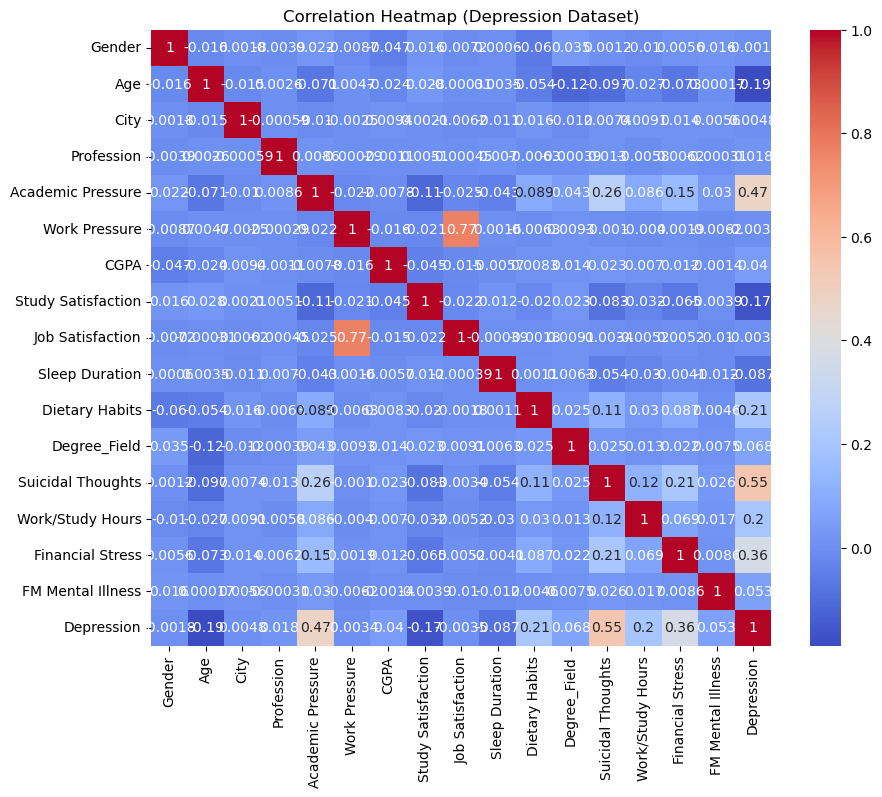

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_dep.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap (Depression Dataset)")
plt.show()

In [34]:
X = df_dep.drop("Depression", axis=1)
y = df_dep["Depression"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = rf.predict(X_test)

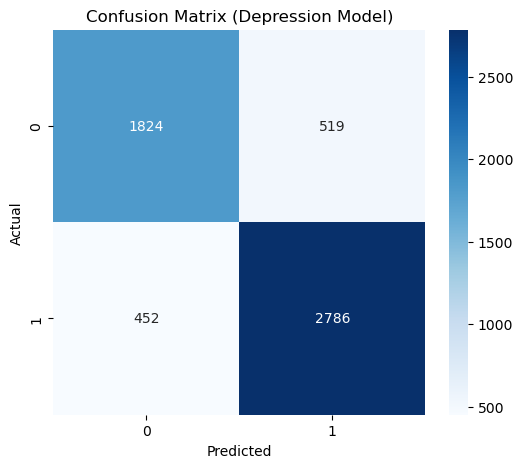

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix (Depression Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
results_table = X_test.copy()

results_table['Actual'] = y_test.values
results_table['Predicted'] = y_pred

results_table['Status'] = results_table.apply(
    lambda row: 'Correct' if row['Actual'] == row['Predicted'] else 'Wrong',
    axis=1
)

results_table = results_table.reset_index()

results_table.head(10)

,index,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree_Field,Suicidal Thoughts,Work/Study Hours,Financial Stress,FM Mental Illness,Actual,Predicted,Status
0,19981,1,1,3,1,2,0,3,3,0,4,1,8,0,3,5,0,0,0,Correct
1,16551,0,1,1,1,2,0,1,5,0,3,3,1,1,1,1,1,0,0,Correct
2,7640,0,2,4,1,3,0,1,4,0,4,2,2,1,1,3,1,0,0,Correct
3,21266,0,1,3,1,5,0,3,2,0,1,3,2,1,2,1,0,1,1,Correct
4,15759,0,1,2,1,5,0,2,2,0,1,1,8,0,1,3,0,1,0,Wrong
5,27146,0,1,3,1,3,0,2,1,0,2,3,3,1,2,1,1,1,1,Correct
6,24868,0,1,3,1,5,0,3,5,0,2,2,8,1,3,2,1,1,1,Correct
7,26237,1,1,3,1,2,0,2,2,0,1,1,8,1,3,1,1,1,1,Correct
8,7260,0,1,3,1,4,0,2,2,0,2,2,8,0,1,2,1,0,0,Correct
9,19527,0,2,2,1,5,0,2,1,0,1,3,7,1,3,5,1,1,1,Correct
